##### F5 — K-means Cluster Analysis (Chemical Yield Unimodal, 4D)

##### Purpose

F5 is a unimodal function. This notebook characterizes F5's cluster structure: the boundary-anchored high-y region, the interior low-y points, and the ridge of moderate-y points along the x1 axis at high x2, x3, x4.

K-means partitions the data so the ridge subset can be extracted cleanly, then a 1D plot of (x1, y) along the ridge reveals the nonlinearity that the surrogate model couldn't capture.

##### Function: F5 — Chemical Yield (Unimodal), 4D
- Domain: [0,1]⁴
- Y range: positive, very wide (0.11 to 8662) — ~4 orders of magnitude
- Preprocessing for clustering: log10(y) for visualization
- Known structure: unimodal (per the label), peak at boundary corner 
  [1,1,1,1]; visible ridge in the data where x2, x3, x4 = 1 and x1 varies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Load F5 data
data = np.load('F5_data.npz')
X = data['X']
y = data['y']

print(f"F5 dataset: {len(X)} points")
print(f"  y range: [{y.min():.2f}, {y.max():.2f}]")
print(f"  Best:    X={X[y.argmax()]}, y={y.max():.2f}")
print(f"  Top 5 y values:")
for idx in np.argsort(y)[-5:][::-1]:
    print(f"    X={X[idx]}, y={y[idx]:.2f}")

# Log transform for visualization
y_log = np.log10(y)
print(f"\n  log10(y) range: [{y_log.min():.2f}, {y_log.max():.2f}]")

F5 dataset: 31 points
  y range: [0.11, 8662.48]
  Best:    X=[1. 1. 1. 1.], y=8662.48
  Top 5 y values:
    X=[1. 1. 1. 1.], y=8662.48
    X=[1.   1.   1.   0.95], y=7786.37
    X=[0.5 1.  1.  1. ], y=4678.34
    X=[0.3 1.  1.  1. ], y=4473.79
    X=[0.1 1.  1.  1. ], y=4441.19

  log10(y) range: [-0.95, 3.94]


##### Step 1 — Silhouette analysis (k = 2 to 6)

In [2]:
sil_scores = {}
for k in range(2, min(7, len(X))):
    km = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)
    print(f"  k={k}: silhouette = {sil_scores[k]:+.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n→ Natural cluster count: k = {best_k}")

  k=2: silhouette = +0.4030
  k=3: silhouette = +0.3461
  k=4: silhouette = +0.3801
  k=5: silhouette = +0.4138
  k=6: silhouette = +0.4089

→ Natural cluster count: k = 5


##### Step 2 — Cluster characterization at natural k

In [3]:
km = KMeans(n_clusters=best_k, n_init=20, random_state=42).fit(X)
labels = km.labels_

print(f"Cluster characterization (k={best_k}):")
print(f"{'cluster':>8} {'n':>4} {'mean_y':>10} {'max_y':>10} {'centroid':>40}")
print("  " + "-" * 80)

best_cluster = int(labels[y.argmax()])
for i in range(best_k):
    members = (labels == i)
    n = int(members.sum())
    mean_y = float(np.mean(y[members]))
    max_y = float(np.max(y[members]))
    centroid = km.cluster_centers_[i]
    marker = " ★" if i == best_cluster else ""
    centroid_str = "[" + ", ".join(f"{v:.3f}" for v in centroid) + "]"
    print(f"{i:>8} {n:>4} {mean_y:>10.2f} {max_y:>10.2f} {centroid_str}{marker}")

print(f"\n→ Current best belongs to cluster {best_cluster}")

Cluster characterization (k=5):
 cluster    n     mean_y      max_y                                 centroid
  --------------------------------------------------------------------------------
       0    8     139.01     355.81 [0.583, 0.469, 0.287, 0.704]
       1   10    3429.95    4678.34 [0.134, 0.959, 0.942, 0.968]
       2    7      34.30      79.73 [0.457, 0.600, 0.505, 0.194]
       3    2    8224.43    8662.48 [1.000, 1.000, 1.000, 0.975] ★
       4    4     442.37    1616.64 [0.250, 0.078, 0.802, 0.543]

→ Current best belongs to cluster 3


##### Step 3 — The boundary peak and the high-y ridge

F5 has a unique structural feature: a *ridge* of moderate-y points 
along the x1 axis where x2 = x3 = x4 = 1.

We characterize the ridge by finding all points where x2, x3, x4 are 
near 1 and ranking them by x1.

In [4]:
# Identify points where x2, x3, x4 are all near 1
ridge_threshold = 0.95
ridge_mask = (X[:, 1] >= ridge_threshold) & (X[:, 2] >= ridge_threshold) & (X[:, 3] >= ridge_threshold)

print(f"\nRidge points (x2, x3, x4 ≥ {ridge_threshold}):")
print(f"  Count: {ridge_mask.sum()}")
if ridge_mask.sum() > 0:
    ridge_X = X[ridge_mask]
    ridge_y = y[ridge_mask]
    sorted_idx = np.argsort(ridge_X[:, 0])
    print(f"  Ridge profile (x1 vs y):")
    for idx in sorted_idx:
        print(f"    x1 = {ridge_X[idx, 0]:.3f}, y = {ridge_y[idx]:.2f}")


Ridge points (x2, x3, x4 ≥ 0.95):
  Count: 8
  Ridge profile (x1 vs y):
    x1 = 0.000, y = 4440.52
    x1 = 0.050, y = 4440.61
    x1 = 0.050, y = 3819.82
    x1 = 0.100, y = 4441.19
    x1 = 0.300, y = 4473.79
    x1 = 0.500, y = 4678.34
    x1 = 1.000, y = 8662.48
    x1 = 1.000, y = 7786.37


##### Step 4 — High-y sub-region characterization

What does the high-y region look like? We define "high-y" as y > 1000 
(approximately the top quintile of F5 values).


In [5]:
y_threshold = 1000.0
high_y_mask = (labels == best_cluster) & (y > y_threshold)

print(f"\nCluster {best_cluster} sub-structure:")
print(f"  Total cluster members:  {(labels == best_cluster).sum()}")
print(f"  High-y sub-region (y > {y_threshold:.0f}): {high_y_mask.sum()}")

if high_y_mask.sum() > 0:
    X_high = X[high_y_mask]
    print(f"  High-y X ranges:")
    for dim_i in range(4):
        dim_lbl = f"x{dim_i+1}"
        print(f"    {dim_lbl}: [{X_high[:, dim_i].min():.3f}, {X_high[:, dim_i].max():.3f}], "
              f"spread = {np.ptp(X_high[:, dim_i]):.3f}")


Cluster 3 sub-structure:
  Total cluster members:  2
  High-y sub-region (y > 1000): 2
  High-y X ranges:
    x1: [1.000, 1.000], spread = 0.000
    x2: [1.000, 1.000], spread = 0.000
    x3: [1.000, 1.000], spread = 0.000
    x4: [0.950, 1.000], spread = 0.050


##### Step 5 — PCA projection for 2D visualization

PCA explained variance: PC1 = 0.528, PC2 = 0.206


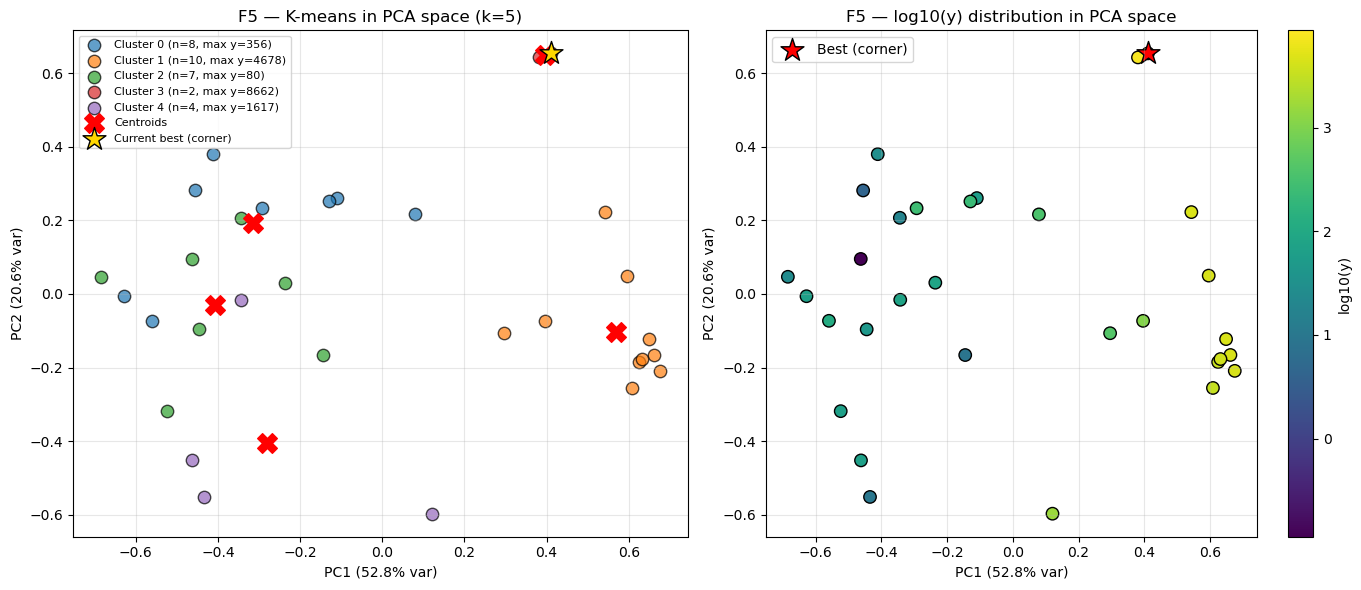

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print(f"PCA explained variance: PC1 = {pca.explained_variance_ratio_[0]:.3f}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: clusters
for i in range(best_k):
    members = labels == i
    ax1.scatter(X_pca[members, 0], X_pca[members, 1],
                s=80, edgecolor='black', alpha=0.7,
                label=f'Cluster {i} (n={members.sum()}, max y={y[members].max():.0f})')
centroids_pca = pca.transform(km.cluster_centers_)
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, color='red', label='Centroids', zorder=5)
best_pca = pca.transform(X[y.argmax()].reshape(1, -1))[0]
ax1.scatter(*best_pca, marker='*', s=300, color='gold',
            edgecolor='black', label='Current best (corner)', zorder=6)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax1.set_title(f'F5 — K-means in PCA space (k={best_k})')
ax1.legend(loc='best', fontsize=8); ax1.grid(alpha=0.3)

# Right: colored by log10(y)
sc = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_log,
                  cmap='viridis', s=80, edgecolor='black')
plt.colorbar(sc, ax=ax2, label='log10(y)')
ax2.scatter(*best_pca, marker='*', s=300, color='red',
            edgecolor='black', label='Best (corner)')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax2.set_title('F5 — log10(y) distribution in PCA space')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('F5_clusters_pca.png', dpi=100, bbox_inches='tight')
plt.show()

##### Step 6 — The x1 ridge profile

F5 has a distinctive ridge in its top values: points where x2, x3, x4 
are all 1 with x1 varying from 0.1 to 1.0. Plotting y vs x1 along this 
ridge reveals the monotonic gradient toward the corner.

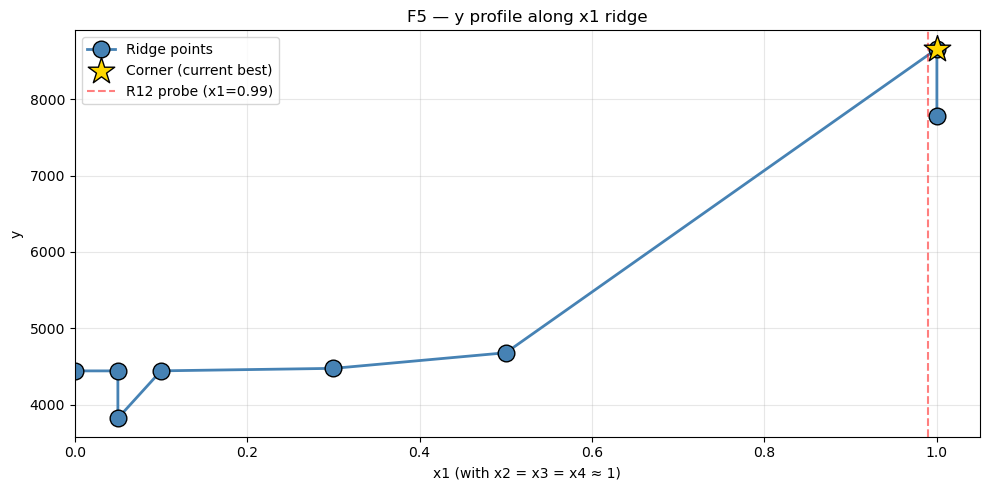

In [7]:
if ridge_mask.sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    ridge_X = X[ridge_mask]
    ridge_y = y[ridge_mask]
    sorted_idx = np.argsort(ridge_X[:, 0])
    
    ax.plot(ridge_X[sorted_idx, 0], ridge_y[sorted_idx], 
            'o-', markersize=12, linewidth=2, color='steelblue',
            markeredgecolor='black', label='Ridge points')
    ax.scatter(X[y.argmax(), 0], y[y.argmax()], 
               marker='*', s=400, color='gold', 
               edgecolor='black', zorder=5, label='Corner (current best)')
    ax.axvline(x=0.99, color='red', linestyle='--', alpha=0.5,
               label='R12 probe (x1=0.99)')
    
    ax.set_xlabel('x1 (with x2 = x3 = x4 ≈ 1)')
    ax.set_ylabel('y')
    ax.set_title('F5 — y profile along x1 ridge')
    ax.grid(alpha=0.3); ax.legend()
    ax.set_xlim(0, 1.05)
    plt.tight_layout()
    plt.savefig('F5_ridge.png', dpi=100, bbox_inches='tight')
    plt.show()

##### Step 7 — Strategic implications

##### What clustering tells us about F5

1. **F5 has a boundary peak at the corner [1,1,1,1]**
2. **A clear ridge exists along x1** at x2 = x3 = x4 = 1, with monotonic 
   gradient toward x1 = 1 (the corner).
3. **The data gap between x1 = 0.5 and x1 = 1.0** in the ridge profile 
   is the most informative target.
4. **K-means at natural k separates interior low-y clusters from the 
   corner-adjacent high-y region.** The corner's geometric position at 
   the search-space boundary means the high-y cluster's centroid is 
   pulled inward by neighbors, the cluster is *anchored* at the 
   boundary even though K-means' centroid metric doesn't reflect this.


##### Reflection

**Past patterns**: The boundary push was a regime-change move 
(per-dim nudge revealed the corner direction was unexplored). Output 
confirmed the corner is the local optimum. Fill the data gap 
needed to characterize the ridge profile.

**Clusters identified?**: F5 has a distinctive structure: a 
boundary-anchored high-y cluster plus a visible ridge connecting it to 
moderate-y points along the x1 axis. K-means with k = best_k identifies 
the discrete clusters; the ridge is visible only when we plot the 
high-y subset directly.

**Model's Effectiveness**: GP-EI on F5 has consistently recommended the 
corner itself. The per-dim nudge test correctly identified the corner direction but cannot help once we're at the corner (all nudges clipped at boundary).

**Clustering parallel**: F5 demonstrates a constrained K-means 
case. The optimal centroid is at the boundary of the input domain. 
Standard K-means doesn't acknowledge boundaries, but the optimization 
strategy must.

**Plotted trends**: F5's y shows dramatic jump (boundary discovery) followed by a confirmation drop. The ridge plot shows the monotonic relationship between x1 and y along the high-y subspace, a clean visual demonstration of the function's structure.